In [1]:
import numpy as np
from scipy.stats import beta
from scipy.special import comb

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
# observed data
k = 3  # number of tea drinkers
n = 5  # number of people surveyed

In [3]:
def unnormalized_posterior(p):
    if p <= 0 or p >= 1:
        return 0

    binom_coeff = comb(n, k)
    return binom_coeff * (p ** k) * ((1 - p) ** (n - k))

In [4]:
# Run sampler
np.random.seed(0)

initial = 0.5
n_samples = 10_000
proposal_stddev = 0.05

samples = np.empty(n_samples)
samples[0] = initial
current_post = unnormalized_posterior(initial)

for t in range(1, n_samples):
    proposal = np.random.normal(samples[t-1], proposal_stddev)
    proposal_post = unnormalized_posterior(proposal)

    # Acceptance ratio
    r = proposal_post / current_post
    if np.random.rand() < r:
        samples[t] = proposal
        current_post = proposal_post
    else:
        samples[t] = samples[t-1]

# Discard burn-in
# burn_in = 1000
post_samples = samples#[burn_in:]

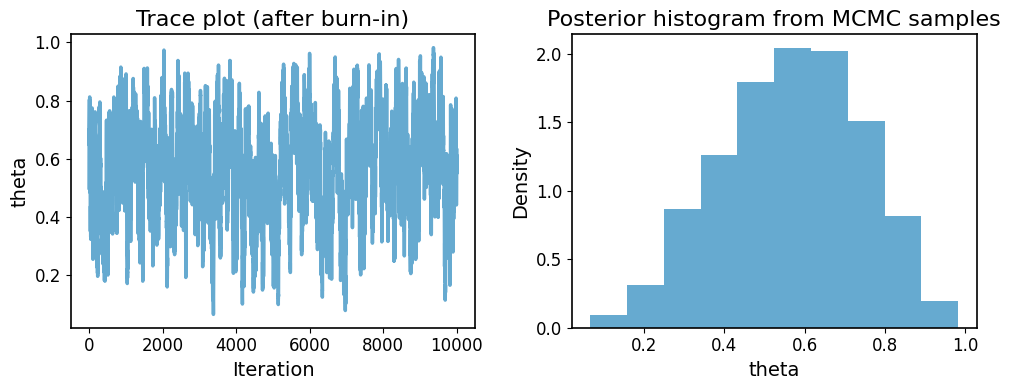

In [5]:
# Plot trace and histogram
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(post_samples, alpha=0.6)
axes[0].set_title("Trace plot (after burn-in)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("theta")

axes[1].hist(post_samples, density=True, alpha=0.6)
axes[1].set_title("Posterior histogram from MCMC samples")
axes[1].set_xlabel("theta")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()